# SAM 2.1 on the smart-crops datasets (cabbage / purple kale / yellow onion)

SAM 2 is a **promptable** segmenter, not a detector - it has no class head and cannot produce
`mAP` on its own the way YOLO-seg or Mask2Former can. So this notebook measures the thing SAM 2
is actually responsible for: **given the object's location, how good is the mask?**

For each crop dataset it reports, on the `test` split:

| stage | prompt | what it tells you |
|---|---|---|
| zero-shot | ground-truth box | out-of-the-box mask quality on crops |
| fine-tuned | ground-truth box | how much the crop-specific fine-tune buys you |

Metrics are **mean IoU** and **mean Dice** against the ground-truth polygon, plus the fraction
of instances above IoU 0.5 / 0.75. These are *not* comparable to YOLO's `mAP50-95(M)` (SAM 2 is
handed the object location), so the optional last section chains a detector into SAM 2 to get a
genuinely comparable end-to-end mask AP.

Only the **prompt encoder + mask decoder** are trained; the Hiera image encoder stays frozen
(that is what `SAM2ImagePredictor.set_image` allows, and it keeps a T4 comfortable).

**Kaggle settings required**
- Accelerator: **GPU T4 x2** or **P100**
- **Internet: ON** (clone + checkpoint download)
- Attach the `smart-crops` dataset

In [1]:
!nvidia-smi
import sys, torch, platform
print("python", platform.python_version())
print("torch ", torch.__version__, "| cuda", torch.version.cuda, "| available", torch.cuda.is_available())
print("gpu   ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
print("bf16  ", torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False)

Tue Sep  8 11:36:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install SAM 2

Cloned into `/kaggle/working/sam2repo` on purpose - cloning into `/kaggle/working/sam2` would
shadow the installed `sam2` package, because the notebook cwd is `/kaggle/working`.

`SAM2_BUILD_CUDA=0` skips the optional connected-components CUDA extension. It only affects
post-processing (removing small holes and specks); everything else is identical, and it saves a
compile that regularly fails on Kaggle images.

In [2]:
%%bash
set -e
cd /kaggle/working

if [ ! -d sam2repo ]; then
  git clone --depth 1 https://github.com/facebookresearch/sam2.git sam2repo
fi

cd sam2repo
SAM2_BUILD_CUDA=0 pip install -q -e .
pip install -q opencv-python-headless "pycocotools>=2.0.7" pandas matplotlib
echo "sam2 installed"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 8.9 MB/s eta 0:00:00
sam2 installed


Cloning into 'sam2repo'...


In [3]:
%%bash
set -e
mkdir -p /kaggle/working/checkpoints
cd /kaggle/working/checkpoints
BASE=https://dl.fbaipublicfiles.com/segment_anything_2/092824

# small = good speed/quality trade-off on a T4. Swap for tiny / base_plus / large.
wget -q -nc $BASE/sam2.1_hiera_small.pt
# wget -q -nc $BASE/sam2.1_hiera_tiny.pt
# wget -q -nc $BASE/sam2.1_hiera_base_plus.pt
# wget -q -nc $BASE/sam2.1_hiera_large.pt
ls -lh

total 176M
-rw-r--r-- 1 root root 176M Sep 29  2024 sam2.1_hiera_small.pt


In [4]:
%%bash
set -eo pipefail
cd /kaggle/working

[ -d sam2repo ] || git clone --depth 1 https://github.com/facebookresearch/sam2.git sam2repo
cd sam2repo
SAM2_BUILD_CUDA=0 pip install --no-build-isolation -e . 2>&1 | tail -40

cd /tmp && python -c "import sam2; print('sam2 ok ->', sam2.__file__)"

  Building editable for SAM-2 (pyproject.toml): started
  Building editable for SAM-2 (pyproject.toml): finished with status 'done'
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-py3-none-any.whl size=13848 sha256=53d40f1dc90d5ee65f79e5468a99aebdfb9028cbac6c242cddf28d25597c1992
  Stored in directory: /tmp/pip-ephem-wheel-cache-dp1vf9a3/wheels/9d/54/e3/dfe24eaa5f4bbb85ba00ed5195dee70a0157a796d93214e02b
Successfully built SAM-2
  Attempting uninstall: SAM-2
    Found existing installation: SAM-2 1.0
    Uninstalling SAM-2-1.0:
      Successfully uninstalled SAM-2-1.0
sam2 ok -> /kaggle/working/sam2repo/sam2/__init__.py


In [5]:
import sys, os
sys.path.insert(0, "/kaggle/working/sam2repo")
os.chdir("/kaggle/working")

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
print("ok")

ok


In [6]:
import os
os.chdir("/kaggle/working")   # never import sam2 from inside the repo root

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

MODEL_CFG  = "configs/sam2.1/sam2.1_hiera_s.yaml"
CHECKPOINT = "/kaggle/working/checkpoints/sam2.1_hiera_small.pt"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# cfg/checkpoint pairs:
#   sam2.1_hiera_t.yaml  -> sam2.1_hiera_tiny.pt
#   sam2.1_hiera_s.yaml  -> sam2.1_hiera_small.pt
#   sam2.1_hiera_b+.yaml -> sam2.1_hiera_base_plus.pt
#   sam2.1_hiera_l.yaml  -> sam2.1_hiera_large.pt

_m = build_sam2(MODEL_CFG, CHECKPOINT, device=DEVICE)
print("built", type(_m).__name__, f"| {sum(p.numel() for p in _m.parameters())/1e6:.1f}M params")
del _m
torch.cuda.empty_cache()

built SAM2Base | 46.1M params


## 2. Find the datasets

Same auto-discovery as the Mask2Former notebook: glob `/kaggle/input` for `*/train/images`
and match each crop by keyword. Hard-code `DATASETS[key]["root"]` if it guesses wrong.

In [7]:
import glob, json, random
from pathlib import Path
import numpy as np
import cv2
from PIL import Image

def discover_yolo_roots(search_root="/kaggle/input"):
    roots = set()
    for p in glob.glob(os.path.join(search_root, "**", "train", "images"), recursive=True):
        roots.add(str(Path(p).parent.parent))
    return sorted(roots)

def n_train_images(root):
    return len(glob.glob(os.path.join(root, "train", "images", "*")))

ALL_ROOTS = discover_yolo_roots()
for r in ALL_ROOTS:
    print(f"  {n_train_images(r):6d} train images   {r}")

KEYWORDS = {"cabbage": ("cabbage", "cabbage"),
            "kale":    ("kale",    "purple_kale"),
            "onion":   ("onion",   "yellow_onion")}

def pick(keyword):
    hits = [r for r in ALL_ROOTS if keyword in r.lower()]
    if not hits:
        return None
    return max(hits, key=lambda r: (n_train_images(r), len(r)))

DATASETS = {key: {"root": pick(kw), "names": [cls]} for kw, (key, cls) in KEYWORDS.items()}
for k, v in DATASETS.items():
    print(f"{k:8s} -> {v['root']}")
assert all(v["root"] for v in DATASETS.values()), "some datasets not found - set root manually"

    1271 train images   /kaggle/input/datasets/muhammadibnerafiq/smart-crops/all/all
     169 train images   /kaggle/input/datasets/muhammadibnerafiq/smart-crops/all/cabbage
      53 train images   /kaggle/input/datasets/muhammadibnerafiq/smart-crops/all/multicrop
     109 train images   /kaggle/input/datasets/muhammadibnerafiq/smart-crops/all/purpleKale
     123 train images   /kaggle/input/datasets/muhammadibnerafiq/smart-crops/all/yellowOnion
     172 train images   /kaggle/input/datasets/muhammadibnerafiq/smart-crops/yellow_onion_extended/yellow_onion_extended
cabbage  -> /kaggle/input/datasets/muhammadibnerafiq/smart-crops/all/cabbage
kale     -> /kaggle/input/datasets/muhammadibnerafiq/smart-crops/all/purpleKale
onion    -> /kaggle/input/datasets/muhammadibnerafiq/smart-crops/yellow_onion_extended/yellow_onion_extended


## 3. YOLO polygons -> instance masks

SAM 2 wants `(image, [binary masks], [xyxy boxes])`. Images and their masks are downscaled so the
long side is at most 1024 - SAM 2 resizes to 1024x1024 internally anyway, and the loss is computed
at image resolution, so this keeps memory sane on large field photos.

In [8]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
MAX_SIDE = 1024

def list_split(root, split):
    d = Path(root) / split
    if not (d / "images").is_dir():
        return []
    imgs = sorted([p for p in (d / "images").iterdir() if p.suffix.lower() in IMG_EXT])
    return [(p, d / "labels" / (p.stem + ".txt")) for p in imgs]

def load_sample(img_path, lbl_path, max_side=MAX_SIDE):
    """-> (RGB uint8 HxWx3, masks uint8 NxHxW, boxes float32 Nx4 xyxy)."""
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        return None
    img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    H0, W0 = img.shape[:2]
    scale = min(1.0, max_side / max(H0, W0))
    if scale < 1.0:
        img = cv2.resize(img, (int(round(W0 * scale)), int(round(H0 * scale))),
                         interpolation=cv2.INTER_AREA)
    H, W = img.shape[:2]

    masks, boxes = [], []
    if Path(lbl_path).exists():
        for line in Path(lbl_path).read_text().splitlines():
            v = line.split()
            if len(v) < 5:
                continue
            c = [float(x) for x in v[1:]]
            if len(c) == 4:                                  # cx cy w h
                cx, cy, w, h = c
                pts = np.array([[cx - w / 2, cy - h / 2], [cx + w / 2, cy - h / 2],
                                [cx + w / 2, cy + h / 2], [cx - w / 2, cy + h / 2]])
            elif len(c) >= 6 and len(c) % 2 == 0:            # polygon
                pts = np.array(c, dtype=np.float64).reshape(-1, 2)
            else:
                continue
            pts[:, 0] = np.clip(pts[:, 0] * W, 0, W - 1)
            pts[:, 1] = np.clip(pts[:, 1] * H, 0, H - 1)
            m = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(m, [pts.astype(np.int32)], 1)
            if m.sum() < 16:
                continue
            ys, xs = np.nonzero(m)
            masks.append(m)
            boxes.append([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1])

    if not masks:
        return img, np.zeros((0, H, W), np.uint8), np.zeros((0, 4), np.float32)
    return img, np.stack(masks), np.asarray(boxes, dtype=np.float32)

  cabbage  train    169 images
  cabbage  valid     48 images
  cabbage  test      24 images
  kale     train    109 images
  kale     valid     31 images
  kale     test      15 images
  onion    train    172 images
  onion    valid     34 images
  onion    test      18 images

image (1024, 576, 3) | masks (1, 1024, 576) | boxes (1, 4)


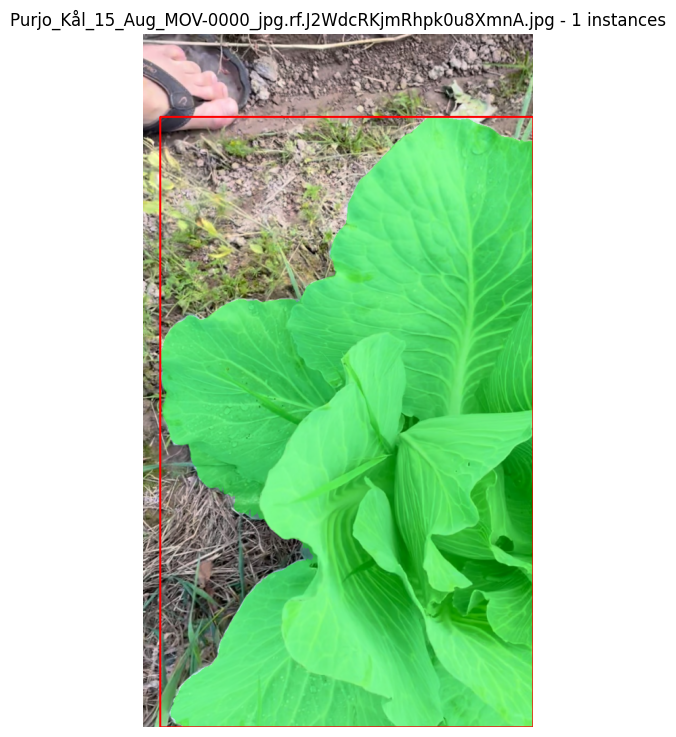

In [9]:
import matplotlib.pyplot as plt

SPLITS = {}
for key, spec in DATASETS.items():
    SPLITS[key] = {}
    for split in ("train", "valid", "test"):
        pairs = list_split(spec["root"], split)
        if pairs:
            SPLITS[key][split] = pairs
        print(f"  {key:8s} {split:6s} {len(pairs):5d} images")

# sanity check on one training image
_img, _m, _b = load_sample(*SPLITS["cabbage"]["train"][0])
print("\nimage", _img.shape, "| masks", _m.shape, "| boxes", _b.shape)
_vis = _img.copy()
if len(_m):
    sel = _m.max(0) > 0
    _vis[sel] = (0.6 * _vis[sel] + 0.4 * np.array([0, 255, 0])).astype(np.uint8)
for bx in _b.astype(int):
    cv2.rectangle(_vis, (bx[0], bx[1]), (bx[2], bx[3]), (255, 0, 0), 2)
plt.figure(figsize=(9, 9)); plt.imshow(_vis); plt.axis("off")
plt.title(f"{SPLITS['cabbage']['train'][0][0].name} - {len(_m)} instances"); plt.show()

## 4. Grad-enabled forward pass

`SAM2ImagePredictor.predict` is wrapped in `@torch.no_grad()`, so it cannot be used for training.
`predict_boxes` below is the same computation as the predictor's internal `_predict`, minus the
no-grad decorator, so gradients reach the prompt encoder and mask decoder.

`set_image` stays under `no_grad` - which is exactly what we want, since the image encoder is
frozen. That also means the expensive Hiera forward runs once per image, not once per prompt.

In [10]:
import torch.nn.functional as F

def predict_boxes(predictor, boxes_xyxy, multimask_output=False):
    """Differentiable box-prompted forward. Returns (mask_logits NxCxHxW, iou_pred NxC)."""
    if not predictor._is_image_set:
        raise RuntimeError("call predictor.set_image(...) first")
    device = predictor.device
    box = torch.as_tensor(np.asarray(boxes_xyxy), dtype=torch.float, device=device)
    unnorm_box = predictor._transforms.transform_boxes(
        box, normalize=True, orig_hw=predictor._orig_hw[-1])          # Bx2x2

    box_coords = unnorm_box.reshape(-1, 2, 2)
    box_labels = torch.tensor([[2, 3]], dtype=torch.int, device=device).repeat(box_coords.shape[0], 1)
    concat_points = (box_coords, box_labels)

    sparse_emb, dense_emb = predictor.model.sam_prompt_encoder(
        points=concat_points, boxes=None, masks=None)

    batched_mode = concat_points[0].shape[0] > 1
    high_res_features = [f[-1].unsqueeze(0) for f in predictor._features["high_res_feats"]]

    low_res_masks, iou_pred, _, _ = predictor.model.sam_mask_decoder(
        image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
        image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_emb,
        dense_prompt_embeddings=dense_emb,
        multimask_output=multimask_output,
        repeat_image=batched_mode,
        high_res_features=high_res_features,
    )
    mask_logits = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1])
    return mask_logits, iou_pred


def make_predictor(checkpoint=CHECKPOINT, cfg=MODEL_CFG, state_dict=None):
    model = build_sam2(cfg, checkpoint, device=DEVICE)
    if state_dict is not None:
        model.load_state_dict(state_dict)
    return SAM2ImagePredictor(model)

AMP_DTYPE = torch.bfloat16 if (DEVICE == "cuda" and torch.cuda.is_bf16_supported()) else torch.float16
print("autocast dtype:", AMP_DTYPE)

autocast dtype: torch.bfloat16


## 5. Evaluation

Every ground-truth box is used as a prompt; the predicted mask is matched 1:1 with the polygon it
came from, so IoU is a direct per-instance mask-quality score. Prompts are chunked so an image
with hundreds of cabbages does not blow up the decoder batch.

In [11]:
CHUNK = 32          # prompts per decoder call

@torch.no_grad()
def evaluate(predictor, pairs, limit=None, chunk=CHUNK, desc=""):
    predictor.model.eval()
    ious, dices = [], []
    n_img = 0
    items = pairs if limit is None else pairs[:limit]
    for i, (ip, lp) in enumerate(items):
        s = load_sample(ip, lp)
        if s is None:
            continue
        img, gt, boxes = s
        if len(gt) == 0:
            continue
        n_img += 1
        with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=(DEVICE == "cuda")):
            predictor.set_image(img)
            for st in range(0, len(boxes), chunk):
                b = boxes[st:st + chunk]
                logits, _ = predict_boxes(predictor, b, multimask_output=False)
                pred = (logits[:, 0].float() > 0)
                g = torch.as_tensor(gt[st:st + chunk], device=pred.device, dtype=torch.bool)
                inter = (pred & g).sum((1, 2)).float()
                union = (pred | g).sum((1, 2)).float()
                psum = pred.sum((1, 2)).float() + g.sum((1, 2)).float()
                ious.append((inter / union.clamp(min=1)).cpu())
                dices.append((2 * inter / psum.clamp(min=1)).cpu())
        if (i + 1) % 50 == 0:
            print(f"  {desc} {i+1}/{len(items)} images", flush=True)

    iou = torch.cat(ious) if ious else torch.zeros(0)
    dice = torch.cat(dices) if dices else torch.zeros(0)
    return {
        "images": n_img,
        "instances": int(iou.numel()),
        "mIoU": float(iou.mean()) if iou.numel() else float("nan"),
        "mDice": float(dice.mean()) if dice.numel() else float("nan"),
        "IoU>0.5": float((iou > 0.5).float().mean()) if iou.numel() else float("nan"),
        "IoU>0.75": float((iou > 0.75).float().mean()) if iou.numel() else float("nan"),
    }

In [12]:
# Zero-shot baseline on every test split. EVAL_LIMIT caps images per dataset while you iterate;
# set it to None for the full split before reporting numbers.
EVAL_LIMIT = 100

zero_shot = {}
predictor = make_predictor()
for key in SPLITS:
    split = "test" if "test" in SPLITS[key] else "valid"
    zero_shot[key] = evaluate(predictor, SPLITS[key][split], limit=EVAL_LIMIT, desc=f"[zs {key}]")
    print(key, zero_shot[key])
del predictor
torch.cuda.empty_cache()

/usr/local/lib/python3.11/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


cabbage {'images': 23, 'instances': 51, 'mIoU': 0.8679777979850769, 'mDice': 0.9192317724227905, 'IoU>0.5': 0.9607843160629272, 'IoU>0.75': 0.8823529481887817}
kale {'images': 15, 'instances': 72, 'mIoU': 0.7726479768753052, 'mDice': 0.8570899963378906, 'IoU>0.5': 0.9166666865348816, 'IoU>0.75': 0.625}
onion {'images': 18, 'instances': 234, 'mIoU': 0.6046337485313416, 'mDice': 0.7323232889175415, 'IoU>0.5': 0.7179487347602844, 'IoU>0.75': 0.2649572789669037}


## 6. Fine-tune the prompt encoder + mask decoder

Loss is BCE + Dice on the mask, plus a small MSE term teaching the IoU head to predict its own
mask quality (SAM 2 uses that score at inference to rank masks).

The image encoder is frozen, so `set_image` runs once per image and every instance in that image
becomes one prompt in the decoder batch - a big speedup over one-instance-per-step training.

In [13]:
import time, math

def finetune(key,
             epochs=8,
             lr=1e-4,
             weight_decay=1e-4,
             max_objs=24,         # prompts per step (cap for memory)
             grad_accum=4,        # images per optimizer step
             score_weight=0.05,
             eval_every=2,
             eval_limit=60,
             seed=42,
             out_dir="/kaggle/working/runs_sam2"):
    os.makedirs(out_dir, exist_ok=True)
    rng = random.Random(seed)
    torch.manual_seed(seed)

    predictor = make_predictor()
    model = predictor.model

    for p in model.image_encoder.parameters():
        p.requires_grad_(False)
    model.image_encoder.eval()

    trainable = list(model.sam_mask_decoder.parameters()) + list(model.sam_prompt_encoder.parameters())
    for p in trainable:
        p.requires_grad_(True)
    print(f"trainable params: {sum(p.numel() for p in trainable)/1e6:.2f}M")

    opt = torch.optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler(DEVICE, enabled=(AMP_DTYPE == torch.float16))

    train_pairs = list(SPLITS[key]["train"])
    val_split = "valid" if "valid" in SPLITS[key] else "test"
    val_pairs = SPLITS[key][val_split]

    total_steps = epochs * math.ceil(len(train_pairs) / grad_accum)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, total_steps))

    best = {"mIoU": -1.0}
    best_path = f"{out_dir}/{key}_best.pt"
    history = []

    for ep in range(1, epochs + 1):
        model.sam_mask_decoder.train()
        model.sam_prompt_encoder.train()
        rng.shuffle(train_pairs)
        t0, run_loss, n_seen = time.time(), 0.0, 0
        opt.zero_grad(set_to_none=True)

        for i, (ip, lp) in enumerate(train_pairs):
            s = load_sample(ip, lp)
            if s is None:
                continue
            img, gt, boxes = s
            if len(gt) == 0:
                continue
            if len(gt) > max_objs:
                idx = rng.sample(range(len(gt)), max_objs)
                gt, boxes = gt[idx], boxes[idx]

            with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=(DEVICE == "cuda")):
                predictor.set_image(img)                       # frozen encoder, no grad
                logits, iou_pred = predict_boxes(predictor, boxes, multimask_output=False)
                logits = logits[:, 0].float()
                g = torch.as_tensor(gt, device=logits.device, dtype=torch.float32)

                bce = F.binary_cross_entropy_with_logits(logits, g)
                prob = torch.sigmoid(logits)
                inter = (prob * g).sum((1, 2))
                dice = 1 - (2 * inter + 1) / (prob.sum((1, 2)) + g.sum((1, 2)) + 1)
                dice = dice.mean()

                with torch.no_grad():
                    hard = (logits > 0)
                    gb = g > 0.5
                    tgt_iou = ((hard & gb).sum((1, 2)).float()
                               / (hard | gb).sum((1, 2)).clamp(min=1).float())
                score = F.mse_loss(iou_pred[:, 0].float(), tgt_iou)

                loss = (bce + dice + score_weight * score) / grad_accum

            scaler.scale(loss).backward()
            run_loss += float(loss) * grad_accum
            n_seen += 1

            if n_seen % grad_accum == 0:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(trainable, 1.0)
                scaler.step(opt); scaler.update()
                opt.zero_grad(set_to_none=True)
                sched.step()

            if (i + 1) % 100 == 0:
                print(f"  ep{ep} {i+1}/{len(train_pairs)}  loss {run_loss/max(1,n_seen):.4f}  "
                      f"lr {sched.get_last_lr()[0]:.2e}  {time.time()-t0:.0f}s", flush=True)

        if n_seen % grad_accum != 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            scaler.step(opt); scaler.update()
            opt.zero_grad(set_to_none=True)

        msg = f"[{key}] epoch {ep}/{epochs}  loss {run_loss/max(1,n_seen):.4f}  {time.time()-t0:.0f}s"
        if ep % eval_every == 0 or ep == epochs:
            m = evaluate(predictor, val_pairs, limit=eval_limit, desc=f"[val {key}]")
            history.append({"epoch": ep, "loss": run_loss / max(1, n_seen), **m})
            msg += f"  | val mIoU {m['mIoU']:.4f}  mDice {m['mDice']:.4f}"
            if m["mIoU"] > best["mIoU"]:
                best = {**m, "epoch": ep}
                torch.save(model.state_dict(), best_path)
                msg += "  <- best, saved"
        print(msg, flush=True)

    with open(f"{out_dir}/{key}_history.json", "w") as f:
        json.dump({"best": best, "history": history}, f, indent=2)

    del predictor, model
    torch.cuda.empty_cache()
    print(f"best val mIoU {best['mIoU']:.4f} (epoch {best.get('epoch')}) -> {best_path}")
    return best_path

### Train one dataset per cell

Comment out the ones you are not running this session. On a T4, an epoch is roughly
`n_train_images x 0.35 s`, so a 1000-image split at 8 epochs lands around 45-60 min.

In [14]:
# ---------------- cabbage ----------------
CKPT_cabbage = finetune("cabbage", epochs=8)

trainable params: 4.22M


/tmp/ipykernel_26/1048647566.py:84: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  run_loss += float(loss) * grad_accum


[cabbage] epoch 1/8  loss 0.1524  53s
  ep2 100/169  loss 0.1069  lr 9.22e-05  33s
[cabbage] epoch 2/8  loss 0.1065  56s  | val mIoU 0.8961  mDice 0.9431  <- best, saved
[cabbage] epoch 3/8  loss 0.0884  55s
  ep4 100/169  loss 0.0664  lr 6.44e-05  32s
[cabbage] epoch 4/8  loss 0.0775  55s  | val mIoU 0.8951  mDice 0.9422
  ep5 100/169  loss 0.0640  lr 4.68e-05  33s
[cabbage] epoch 5/8  loss 0.0661  55s
  ep6 100/169  loss 0.0571  lr 2.96e-05  32s
[cabbage] epoch 6/8  loss 0.0577  55s  | val mIoU 0.8935  mDice 0.9412
  ep7 100/169  loss 0.0557  lr 1.50e-05  32s
[cabbage] epoch 7/8  loss 0.0530  54s
  ep8 100/169  loss 0.0501  lr 4.73e-06  31s
[cabbage] epoch 8/8  loss 0.0502  55s  | val mIoU 0.8943  mDice 0.9417
best val mIoU 0.8961 (epoch 2) -> /kaggle/working/runs_sam2/cabbage_best.pt


In [15]:
# ---------------- purple kale ----------------
# CKPT_kale = finetune("kale", epochs=8)

In [16]:
# ---------------- yellow onion ----------------
# CKPT_onion = finetune("onion", epochs=8)

## 7. Zero-shot vs fine-tuned

In [17]:
import pandas as pd

FT_CKPTS = {k: f"/kaggle/working/runs_sam2/{k}_best.pt" for k in SPLITS}

rows = []
for key in SPLITS:
    rows.append({"dataset": key, "model": "sam2.1-s zero-shot", **zero_shot[key]})

for key in SPLITS:
    path = FT_CKPTS[key]
    if not os.path.exists(path):
        print(f"skip {key}: {path} not found (not fine-tuned this session)")
        continue
    sd = torch.load(path, map_location="cpu", weights_only=True)
    predictor = make_predictor(state_dict=sd)
    split = "test" if "test" in SPLITS[key] else "valid"
    m = evaluate(predictor, SPLITS[key][split], limit=EVAL_LIMIT, desc=f"[ft {key}]")
    rows.append({"dataset": key, "model": "sam2.1-s fine-tuned", **m})
    print(key, m)
    del predictor
    torch.cuda.empty_cache()

df = pd.DataFrame(rows)[["dataset", "model", "images", "instances", "mIoU", "mDice", "IoU>0.5", "IoU>0.75"]]
df.to_csv("/kaggle/working/sam2_results.csv", index=False)
df.round(4)

/usr/local/lib/python3.11/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


cabbage {'images': 23, 'instances': 51, 'mIoU': 0.9114353060722351, 'mDice': 0.9505149126052856, 'IoU>0.5': 0.9803921580314636, 'IoU>0.75': 0.9607843160629272}
skip kale: /kaggle/working/runs_sam2/kale_best.pt not found (not fine-tuned this session)
skip onion: /kaggle/working/runs_sam2/onion_best.pt not found (not fine-tuned this session)


,dataset,model,images,instances,mIoU,mDice,IoU>0.5,IoU>0.75
0,cabbage,sam2.1-s zero-shot,23,51,0.8680,0.9192,0.9608,0.8824
1,kale,sam2.1-s zero-shot,15,72,0.7726,0.8571,0.9167,0.6250
2,onion,sam2.1-s zero-shot,18,234,0.6046,0.7323,0.7179,0.2650
3,cabbage,sam2.1-s fine-tuned,23,51,0.9114,0.9505,0.9804,0.9608


/usr/local/lib/python3.11/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


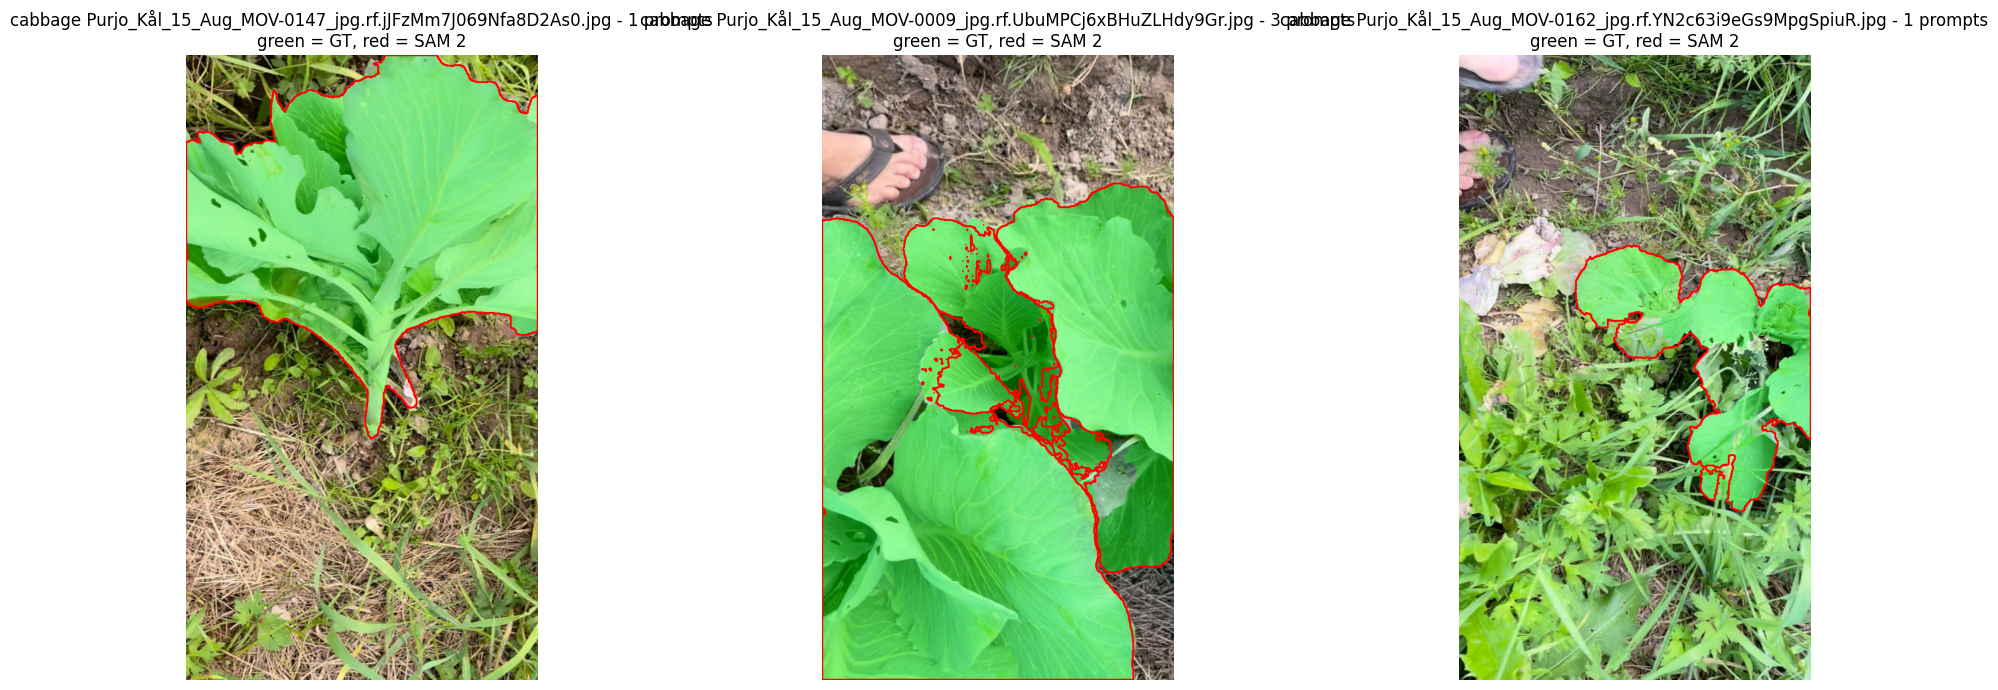

In [18]:
# qualitative: GT polygon (green) vs SAM 2 mask (red outline), prompted with the GT box
def show_predictions(key, ckpt=None, split="test", n=3, seed=0):
    sd = torch.load(ckpt, map_location="cpu", weights_only=True) if ckpt and os.path.exists(ckpt) else None
    predictor = make_predictor(state_dict=sd)
    predictor.model.eval()
    pairs = list(SPLITS[key][split])
    random.Random(seed).shuffle(pairs)

    fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
    for ax, (ip, lp) in zip(np.atleast_1d(axes), pairs[:n]):
        img, gt, boxes = load_sample(ip, lp)
        vis = img.copy()
        if len(boxes):
            with torch.no_grad(), torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=(DEVICE == "cuda")):
                predictor.set_image(img)
                logits, _ = predict_boxes(predictor, boxes[:CHUNK], multimask_output=False)
                pred = (logits[:, 0].float() > 0).cpu().numpy().astype(np.uint8)
            gsel = gt[:CHUNK].max(0) > 0
            vis[gsel] = (0.65 * vis[gsel] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)
            for m in pred:
                cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(vis, cnts, -1, (255, 0, 0), 2)
        ax.imshow(vis); ax.axis("off")
        ax.set_title(f"{key} {ip.name} - {len(boxes)} prompts\ngreen = GT, red = SAM 2")
    plt.tight_layout(); plt.show()
    del predictor
    torch.cuda.empty_cache()

show_predictions("cabbage", ckpt=FT_CKPTS["cabbage"])
# show_predictions("kale", ckpt=FT_CKPTS["kale"])
# show_predictions("onion", ckpt=FT_CKPTS["onion"])

## 8. Optional: detector -> SAM 2, for a number comparable to YOLO / Mask2Former

The table above hands SAM 2 the ground-truth box, so it is a mask-quality ceiling, not a
detection score. To get real COCO mask AP you need a detector in front. Point `DET_WEIGHTS` at a
`best.pt` from the YOLO26s-seg runs (upload it as a Kaggle dataset) and this cell runs
YOLO boxes -> SAM 2 masks -> `pycocotools` mask AP on the same test split.

Leave `DET_WEIGHTS = None` to skip.

In [19]:
DET_WEIGHTS = None   # e.g. "/kaggle/input/yolo26s-crops/cabbage_best.pt"
DET_KEY = "cabbage"

if DET_WEIGHTS:
    from pycocotools import mask as mask_utils
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
    from ultralytics import YOLO

    det = YOLO(DET_WEIGHTS)
    sd = torch.load(FT_CKPTS[DET_KEY], map_location="cpu", weights_only=True) \
        if os.path.exists(FT_CKPTS[DET_KEY]) else None
    predictor = make_predictor(state_dict=sd)
    predictor.model.eval()

    images, annotations, results = [], [], []
    ann_id = 1
    for img_id, (ip, lp) in enumerate(SPLITS[DET_KEY]["test"], start=1):
        img, gt, _ = load_sample(ip, lp)
        H, W = img.shape[:2]
        images.append({"id": img_id, "file_name": ip.name, "width": W, "height": H})
        for m in gt:
            rle = mask_utils.encode(np.asfortranarray(m))
            rle["counts"] = rle["counts"].decode()
            annotations.append({"id": ann_id, "image_id": img_id, "category_id": 1,
                                "segmentation": rle, "area": float(m.sum()),
                                "bbox": list(map(float, mask_utils.toBbox(rle))), "iscrowd": 0})
            ann_id += 1

        r = det.predict(img[:, :, ::-1].copy(), verbose=False, conf=0.25)[0]
        if r.boxes is None or len(r.boxes) == 0:
            continue
        boxes = r.boxes.xyxy.cpu().numpy()
        scores = r.boxes.conf.cpu().numpy()
        with torch.no_grad(), torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=(DEVICE == "cuda")):
            predictor.set_image(img)
            preds = []
            for st in range(0, len(boxes), CHUNK):
                lg, _ = predict_boxes(predictor, boxes[st:st + CHUNK], multimask_output=False)
                preds.append((lg[:, 0].float() > 0).cpu().numpy().astype(np.uint8))
        preds = np.concatenate(preds, 0)
        for m, sc in zip(preds, scores):
            rle = mask_utils.encode(np.asfortranarray(m))
            rle["counts"] = rle["counts"].decode()
            results.append({"image_id": img_id, "category_id": 1,
                            "segmentation": rle, "score": float(sc)})

    gt_json = {"images": images, "annotations": annotations,
               "categories": [{"id": 1, "name": DATASETS[DET_KEY]["names"][0]}]}
    with open("/kaggle/working/_gt.json", "w") as f:
        json.dump(gt_json, f)
    with open("/kaggle/working/_dt.json", "w") as f:
        json.dump(results, f)

    coco_gt = COCO("/kaggle/working/_gt.json")
    coco_dt = coco_gt.loadRes("/kaggle/working/_dt.json")
    e = COCOeval(coco_gt, coco_dt, "segm")
    e.evaluate(); e.accumulate(); e.summarize()
    del predictor
    torch.cuda.empty_cache()
else:
    print("DET_WEIGHTS is None - skipping the end-to-end mask AP section")

DET_WEIGHTS is None - skipping the end-to-end mask AP section


## 9. Trim the output directory

In [20]:
def keep_only_best(root="/kaggle/working"):
    removed, freed = 0, 0
    for f in glob.glob(f"{root}/**/*.pt", recursive=True):
        if os.path.basename(f).endswith("_best.pt"):
            continue
        if "/checkpoints/" in f:          # the downloaded base checkpoint
            continue
        freed += os.path.getsize(f); os.remove(f); removed += 1
        print("removed:", f)
    print(f"\n{removed} files removed, {freed/1e6:.1f} MB freed")
    for k in sorted(glob.glob(f"{root}/**/*_best.pt", recursive=True)):
        print(" kept", k, f"({os.path.getsize(k)/1e6:.1f} MB)")

keep_only_best()
!du -sh /kaggle/working


0 files removed, 0.0 MB freed
 kept /kaggle/working/runs_sam2/cabbage_best.pt (184.5 MB)
472M	/kaggle/working
